In [4]:
import torch 
from typing import Tuple, List, Union
from abc import ABC, abstractmethod

class KernelBasis(torch.nn.Module, ABC):
    
    def __init__(self, dim: int, shape: Tuple[int, int]):
        r"""
        
        Abstract class for implementing the basis of a kernel space.
        A kernel space is the space of functions in the form:
        
        .. math::
            \mathcal{K} := \{ \kappa: X \to \mathbb{R}^{c_\text{out} \times c_\text{in}} \}
        
        where :math:`X` is the base space on which the kernel is defined.
        For instance, for planar images :math:`X = \R^2`.

        One can also access the dimensionality ``dim`` of this basis via the ``len()`` method.
        
        Args:
            dim (int): the dimensionality of the basis :math:`|\mathcal{K}|` (number of elements)
            shape (tuple): a tuple containing :math:`c_\text{out}` and :math:`c_\text{in}`
            
        Attributes:
            ~.dim (int): the dimensionality of the basis :math:`|\mathcal{K}|` (number of elements)
            ~.shape (tuple): a tuple containing :math:`c_\text{out}` and :math:`c_\text{in}`
            
        """
        assert isinstance(dim, int), (dim, type(dim))
        assert isinstance(shape, tuple) and len(shape) == 2, shape
        
        assert dim >= 0
        
        if dim == 0:
            raise EmptyBasisException()
        
        self.dim = dim
        self.shape = shape

        super(KernelBasis, self).__init__()

    @abstractmethod
    def sample(self, points: torch.Tensor, out: torch.Tensor = None) -> torch.Tensor:
        r"""
        Sample the continuous basis elements on discrete points in ``points``.
        Optionally, store the resulting multidimentional array in ``out``.

        ``points`` must be an array of shape `(N, D)`, where `D` is the dimensionality of the (parametrization of the)
        base space while `N` is the number of points.

        Args:
            points (~torch.Tensor): points where to evaluate the basis elements
            out (~torch.Tensor, optional): pre-existing array to use to store the output

        Returns:
            the sampled basis

        """
        pass

    def forward(self, points: torch.Tensor, out: torch.Tensor = None) -> torch.Tensor:
        r"""
            Alias for :meth:`~escnn.kernels.KernelBasis.sample`.
        """
        return self.sample(points, out=out)

    def __len__(self):
        return self.dim

    def __iter__(self):
        for i in range(self.dim):
            yield self[i]

    @abstractmethod
    def __getitem__(self, idx: int) -> dict:
        pass
    
    @abstractmethod
    def __hash__(self):
        pass
    
    @abstractmethod
    def __eq__(self, other):
        pass



class GaussianRadialProfile(KernelBasis):
    
    def __init__(self, radii: List[float], sigma: Union[List[float], float]):
        r"""

        Basis for kernels defined over a radius in :math:`\R^+_0`.

        Each basis element is defined as a Gaussian function.
        Different basis elements are centered at different radii (``rings``) and can possibly be associated with
        different widths (``sigma``).

        More precisely, the following basis is implemented:

        .. math::

            \mathcal{B} = \left\{ b_i (r) :=  \exp \left( \frac{ \left( r - r_i \right)^2}{2 \sigma_i^2} \right) \right\}_i

        In order to build a complete basis of kernels, you should combine this basis with a basis which defines the
        angular profile, see for example :class:`~escnn.kernels.SphericalShellsBasis` or
        :class:`~escnn.kernels.CircularShellsBasis`.

        Args:
            radii (list): centers of each basis element. They should be different and spread to cover all
                domain of interest
            sigma (list or float): widths of each element. Can potentially be different.


        """
        
        if isinstance(sigma, float):
            sigma = [sigma] * len(radii)
        
        assert len(radii) == len(sigma)
        assert isinstance(radii, list)
        
        for r in radii:
            assert r >= 0.
        
        for s in sigma:
            assert s > 0.
        
        super(GaussianRadialProfile, self).__init__(len(radii), (1, 1))
        
        self.register_buffer('radii', torch.tensor(radii, dtype=torch.float32).reshape(1, -1, 1, 1))
        self.register_buffer('sigma', torch.tensor(sigma, dtype=torch.float32).reshape(1, -1, 1, 1))
    
    def sample(self, radii: torch.Tensor, out: torch.Tensor = None) -> torch.Tensor:
        r"""

        Sample the continuous basis elements on the discrete set of radii in ``radii``.
        Optionally, store the resulting multidimentional array in ``out``.

        ``radii`` must be an array of shape `(N, 1)`, where `N` is the number of points.

        Args:
            radii (~torch.Tensor): radii where to evaluate the basis elements
            out (~torch.Tensor, optional): pre-existing array to use to store the output

        Returns:
            the sampled basis

        """
        assert len(radii.shape) == 2
        assert radii.shape[1] == 1
        S = radii.shape[0]
        
        if out is None:
            out = torch.empty((S, self.dim, self.shape[0], self.shape[1]), device=radii.device, dtype=radii.dtype)
        
        assert out.shape == (S, self.dim, self.shape[0], self.shape[1])
        
        radii = radii.reshape(-1, 1, 1, 1)

        assert not torch.isnan(radii).any()

        d = (self.radii - radii) ** 2

        if radii.requires_grad:
            out[:] = torch.exp(-0.5 * d / self.sigma ** 2)
        else:
            out = torch.exp(-0.5 * d / self.sigma ** 2, out=out)

        return out
    
    def __getitem__(self, r):
        assert r < self.dim
        return {"radius": self.radii[0, r, 0, 0].item(), "sigma": self.sigma[0, r, 0, 0].item(), "idx": r}
    
    def __eq__(self, other):
        if isinstance(other, GaussianRadialProfile):
            return (
                        torch.allclose(self.radii, other.radii.to(self.radii.device))
                    and torch.allclose(self.sigma, other.sigma.to(self.sigma.device))
            )
        else:
            return False
    
    def __hash__(self):
        return hash(self.radii.cpu().numpy().tobytes()) + hash(self.sigma.cpu().numpy().tobytes())

In [24]:
layer = GaussianRadialProfile(radii=[0.5, 0.7, 0.8], sigma=[1, 0.1, 0.3])

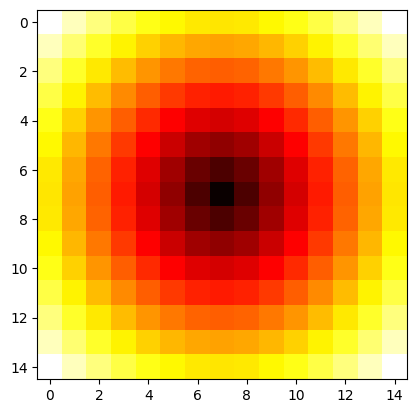

In [25]:
# Create a 15x15 grid and compute radial distances
# Create coordinate grids for 15x15 filter
size = 15
center = size // 2  # center at (7, 7)

# Create coordinate meshgrid
y, x = torch.meshgrid(torch.arange(size, dtype=torch.float32), 
                      torch.arange(size, dtype=torch.float32), 
                      indexing='ij')

# Compute radial distances from center
radial_distances = torch.sqrt((x - center)**2 + (y - center)**2)

# Normalize distances so that the border (maximum distance) equals 1
max_distance = radial_distances.max()
radial_distances = radial_distances / 7

plt.imshow(radial_distances, cmap='hot', interpolation='nearest')

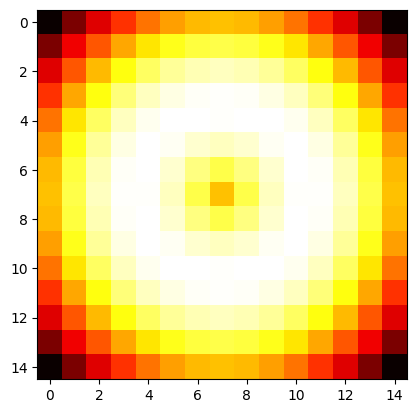

In [26]:
from einops import rearrange
points = rearrange(radial_distances, 'h w -> (h w) 1')
radial_filter = layer(points)

plt.imshow(radial_filter[:, 0].reshape(15, 15).detach().cpu(), cmap='hot', interpolation='nearest')

In [59]:
# Suppose a 5x5 kernel grid centered at (0,0); compute radii for all pixels
coords = [(x, y) for y in range(-5, 6) for x in range(-5, 6)]
r = torch.tensor([[ (x**2 + y**2)**0.5 ] for (x, y) in coords])  # shape (25, 1)


rings = [0, 1.5, 3, 4, 5]             # radii in pixels
sigma = [0.005,0.6, 0.6, 0.6, 0.4]     # widths for center / inner / outer

grp = GaussianRadialProfile(rings, sigma)
R = grp.sample(r)   # shape (25, 3, 1, 1) -> 25 points × 3 radial basis values
R.shape

torch.Size([121, 5, 1, 1])

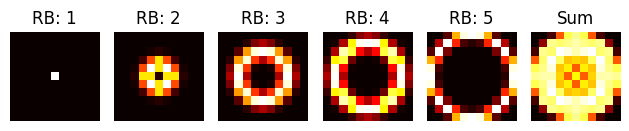

In [66]:
# Visualize the radial basis functions
import matplotlib.pyplot as plt

sum = torch.zeros((11, 11)) 
for i in range(R.shape[1]):
    plt.subplot(1, R.shape[1]+1, i + 1)
    sum += R[:, i].reshape(11,11)
    plt.imshow(R[:, i].reshape(11,11).detach().cpu(), cmap='hot')
    plt.title(f'RB: {i + 1}')
    plt.axis('off')
plt.subplot(1, R.shape[1]+1, R.shape[1]+1)
plt.imshow(sum.detach().cpu(), cmap='hot')
plt.title('Sum')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import math
from typing import Sequence, Tuple, Union
import torch
import torch.nn as nn
import torch.nn.functional as F

def escnn_style_rings_sigmas(kernel_size: int, n_rings: int):
    """
    Rings: linearly spaced from 0 to floor((k-1)/2).
    Sigmas: 0.005 at the center (if present), 0.6 on interior, 0.4 on outermost.
    """
    assert kernel_size % 2 == 1
    rmax = (kernel_size - 1) // 2
    rings = torch.linspace(0.0, float(rmax), steps=n_rings).tolist()
    if rings[0] == 0.0:
        sigma = [0.005] + [0.6] * (n_rings - 2) + [0.4] if n_rings > 1 else [0.4]
    else:
        sigma = [0.6] * (n_rings - 1) + [0.4]
    return rings, sigma


class RadialGaussianConv2d(nn.Module):
    """
    2D convolution with a radially symmetric kernel parameterized as a
    linear combination of Gaussian rings.

    Kernel(x, y) = sum_j coeff[out, in, j] * exp(-(r - rings[j])^2 / (2*sigma[j]^2)),
    where r = sqrt(x^2 + y^2) on the kernel grid.

    Simplified: stride=1, padding=0 (valid), groups=1, dilation=1, bias=None.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        rings: Sequence[float],
        sigma: Union[float, Sequence[float]],
    ):
        super().__init__()
        if isinstance(sigma, (int, float)):
            sigma = [float(sigma)] * len(rings)
        assert len(rings) == len(sigma) and len(rings) > 0, "rings and sigma must match and be non-empty"
        for r in rings:
            assert r >= 0.0
        for s in sigma:
            assert s > 0.0

        self.in_channels = int(in_channels)
        self.out_channels = int(out_channels)
        self.kernel_size = int(kernel_size)

        # Learnable ring coefficients: (out, in, R)
        R = len(rings)
        self.coeff = nn.Parameter(torch.zeros(out_channels, in_channels, R))

        # Fixed ring parameters (buffers)
        self.register_buffer("rings", torch.tensor(rings, dtype=torch.get_default_dtype()))   # (R,)
        self.register_buffer("sigma", torch.tensor(sigma, dtype=torch.get_default_dtype()))   # (R,)

        # Pre-sample the radial basis on the kernel grid: (R, k, k)
        basis = self._build_radial_basis(self.kernel_size, self.rings, self.sigma)
        self.register_buffer("_basis", basis)  # (R, k, k)

        self.reset_parameters()

    def reset_parameters(self):
        fan_in = self.in_channels * self.coeff.shape[-1]  # in_channels * n_rings
        bound = 1.0 / math.sqrt(max(1, fan_in))
        nn.init.uniform_(self.coeff, -bound, bound)

    @staticmethod
    def _radius_grid(k: int, device=None, dtype=None) -> torch.Tensor:
        """Radius r = sqrt(x^2 + y^2) over a k×k grid centered at 0."""
        ys = torch.arange(k, device=device, dtype=dtype) - (k - 1) / 2.0
        xs = torch.arange(k, device=device, dtype=dtype) - (k - 1) / 2.0
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        return torch.sqrt(yy ** 2 + xx ** 2)  # (k, k)

    @classmethod
    def _build_radial_basis(cls, k: int, rings: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        r = cls._radius_grid(k, device=rings.device, dtype=rings.dtype)  # (k, k)
        rings = rings.view(-1, 1, 1)   # (R,1,1)
        sigma = sigma.view(-1, 1, 1)   # (R,1,1)
        return torch.exp(-0.5 * (r.unsqueeze(0) - rings) ** 2 / (sigma ** 2))  # (R,k,k)

    def _assemble_weight(self, dtype=None) -> torch.Tensor:
        # (out, in, R) × (R, k, k) -> (out, in, k, k)
        basis = self._basis.to(dtype=dtype if dtype is not None else self._basis.dtype)
        return torch.einsum("oir,rhw->oihw", self.coeff, basis)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self._assemble_weight(dtype=x.dtype)
        # Valid convolution: stride=1, padding=0, dilation=1, groups=1, bias=None
        return F.conv2d(x, w, bias=None, stride=1, padding=0, dilation=1, groups=1)

    @torch.no_grad()
    def current_kernel(self) -> torch.Tensor:
        """Get the assembled kernel: (out_channels, in_channels, k, k)."""
        return self._assemble_weight()


max error: 5.722e-06, rel L2: 3.681e-07


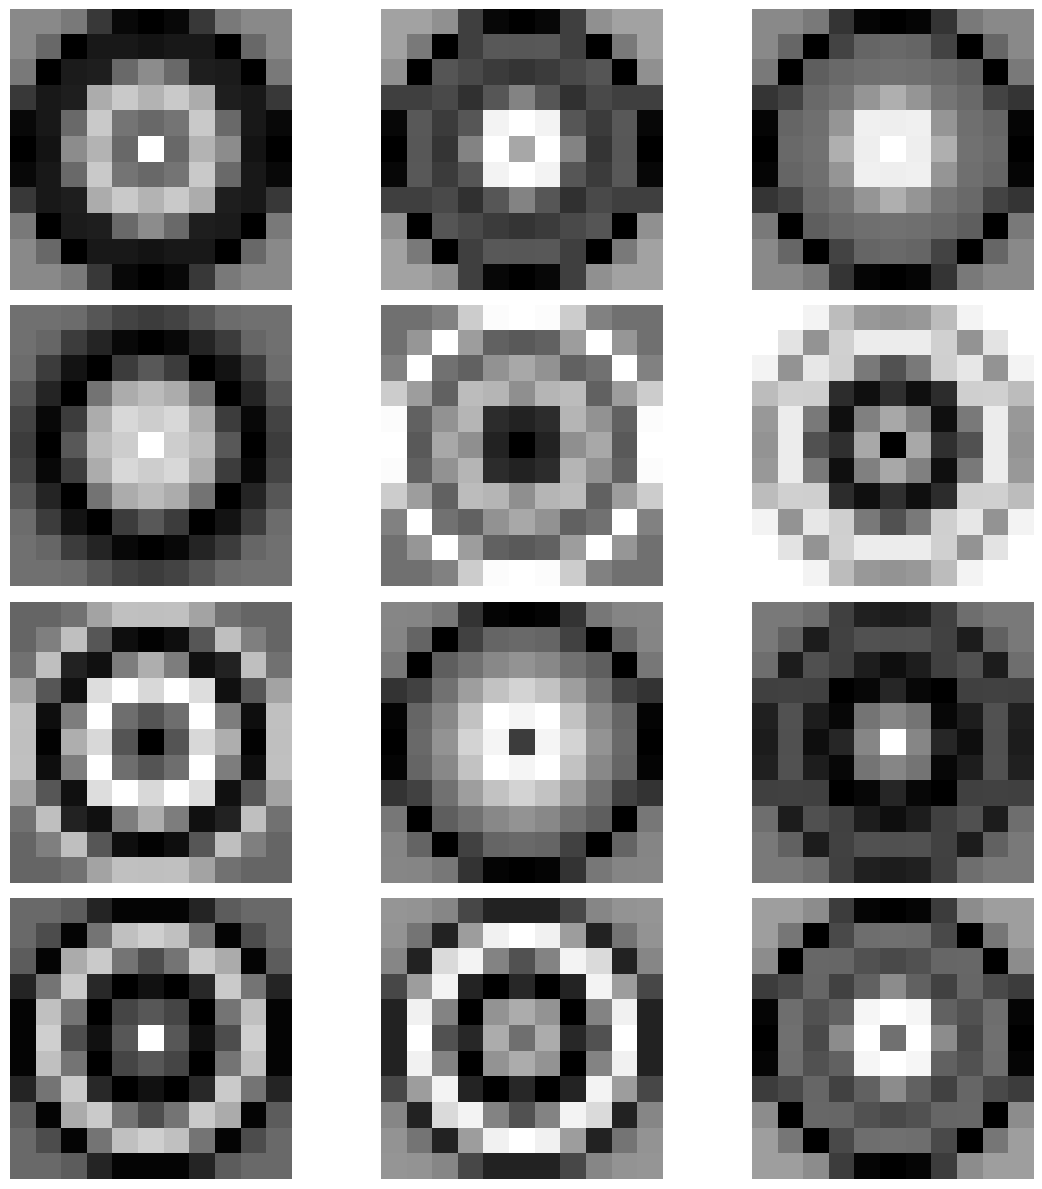

In [ ]:
# Build layer
rings, sigma = escnn_style_rings_sigmas(kernel_size=11, n_rings=5)
layer = RadialGaussianConv2d(in_channels=3, out_channels=4, kernel_size=11,
                             rings=rings, sigma=sigma)

# Random input and its 90° rotation
x = torch.randn(1, 3, 96, 96)                         # (B,C,H,W)
x_rot = torch.rot90(x, k=1, dims=(2, 3))              # rotate 90° ccw

# Apply layer (valid conv)
y      = layer(x)                                     # (1,4,86,86)
y_rot  = layer(x_rot)                                 # (1,4,86,86)
y_back = torch.rot90(y_rot, k=3, dims=(2, 3))         # rotate output back

# Compare (should be ~0 up to float error)
max_err = (y - y_back).abs().max().item()
rel_l2  = ((y - y_back).pow(2).sum() / (y.pow(2).sum().clamp_min(1e-12))).sqrt().item()
print(f"max error: {max_err:.3e}, rel L2: {rel_l2:.3e}")


# Plot kernel
import matplotlib.pyplot as plt

def plot_kernel(kernel: torch.Tensor):
    """Plot the kernel weights."""
    kernel = kernel.detach().cpu()
    fig, axes = plt.subplots(nrows=kernel.shape[0], ncols=kernel.shape[1], figsize=(12, 12))
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            ax = axes[i, j]
            ax.imshow(kernel[i, j].squeeze(), cmap="gray")
            ax.axis("off")
    plt.tight_layout()
    plt.show()